## 1. Imports et paramètres

In [86]:
import os
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.sparse import csr_matrix
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import normalize

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
BLEU, ROUGE, ENCRE = "#2a78d6", "#e34948", "#52514e"

In [87]:
DATA_DIR = "..\\ml-32m"

_CANDIDATS = [os.environ.get("ML32M_DIR"), DATA_DIR, "ml-32m", "..\\..\\ml-32m",
              "data\\raw\\movielens\\ml-32m", "projet\\data\\raw\\movielens\\ml-32m",
              "..\\projet\\data\\raw\\movielens\\ml-32m"]
DATA_DIR = next((d for d in _CANDIDATS if d and os.path.exists(os.path.join(d, "ratings.csv"))), DATA_DIR)

RATINGS_PATH = os.path.join(DATA_DIR, "ratings.csv")
MOVIES_PATH = os.path.join(DATA_DIR, "movies.csv")

SAMPLE_SIZE_USERS = None   # None = tous les utilisateurs ; sinon un entier, ex. 50_000

N_COMPONENTS = 50          # dimensions du vecteur "goûts" par utilisateur (sortie de la SVD)
N_CLUSTERS = 8          # déterminé en section 4
MIN_VOTES_IN_CLUSTER = 20  # lissage bayésien de la note d'un film dans un cluster
TOP_N_RECOMMENDATIONS = 10
SILHOUETTE_SAMPLE = 20_000

print(f"données lues depuis {os.path.abspath(DATA_DIR)}")

données lues depuis c:\Users\paul_\OneDrive\Documents\ESIEA\DataVisualisation\git\movie-boxoffice-recommender\ml-32m


## 2. Chargement des données

In [88]:
ratings = pd.read_csv(RATINGS_PATH, usecols=["userId", "movieId", "rating"],
                      dtype={"userId": "int32", "movieId": "int32", "rating": "float32"})
movies = pd.read_csv(MOVIES_PATH)

if SAMPLE_SIZE_USERS is not None:
    tires = (pd.Series(ratings["userId"].unique())
             .sample(n=SAMPLE_SIZE_USERS, random_state=RANDOM_STATE))
    ratings = ratings[ratings["userId"].isin(set(tires))]

print(f"Notes : {len(ratings):,} | Utilisateurs : {ratings['userId'].nunique():,} | "
      f"Films : {ratings['movieId'].nunique():,}")

Notes : 32,000,204 | Utilisateurs : 200,948 | Films : 84,432


## 3. Matrice utilisateur × film


In [89]:
user_ids = np.sort(ratings["userId"].unique())
movie_ids = np.sort(ratings["movieId"].unique())

user_to_idx = {u: i for i, u in enumerate(user_ids)}
movie_to_idx = {m: i for i, m in enumerate(movie_ids)}
idx_to_user = {i: u for u, i in user_to_idx.items()}

rows = ratings["userId"].map(user_to_idx).to_numpy()
cols = ratings["movieId"].map(movie_to_idx).to_numpy()
data = np.ones(len(ratings), dtype=np.float32)

user_item_matrix = csr_matrix((data, (rows, cols)), shape=(len(user_ids), len(movie_ids)))
n_ratings_per_user = np.asarray(user_item_matrix.sum(axis=1)).ravel()

print(f"Matrice utilisateur x film : {user_item_matrix.shape}, "
      f"densité = {user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1]):.4%}")

Matrice utilisateur x film : (200948, 84432), densité = 0.1886%


## 4. Réduction de dimension

In [90]:
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
user_embeddings = svd.fit_transform(user_item_matrix)
user_vectors = normalize(user_embeddings)

print(f"Variance expliquée cumulée ({N_COMPONENTS} composantes) : {svd.explained_variance_ratio_.sum():.2%}")
print(f"Forme des vecteurs utilisateurs : {user_vectors.shape}")
print(f"Poids relatif axe 1 / axe {N_COMPONENTS} : x{svd.singular_values_[0] / svd.singular_values_[-1]:.1f}")

correlation_activite = np.corrcoef(user_embeddings[:, 0], n_ratings_per_user)[0, 1]
print(f"Corrélation axe 1 / nombre de films notés : r = {correlation_activite:+.3f}")

Variance expliquée cumulée (50 composantes) : 34.71%
Forme des vecteurs utilisateurs : (200948, 50)
Poids relatif axe 1 / axe 50 : x13.1
Corrélation axe 1 / nombre de films notés : r = +0.863


## 5. Choix du nombre de clusters

> Deux critères sont nécessaires ici :
>
> - **la silhouette** répond à « existe-t-il des groupes séparés ? ». Elle va rester basse (~0,12) : il n'existe pas
>   de publics nettement séparés dans MovieLens, le goût est un continuum. Ce n'est pas un défaut du code,
>   c'est une propriété des données — viser une belle silhouette est un objectif inatteignable ici ;
> - **la stabilité** répond à « ce découpage est-il reproductible ? ». On apprend deux k-means sur deux
>   sous-échantillons disjoints et on mesure leur accord par l'ARI (1 = partitions identiques, 0 = hasard).
>   Un `k` dont le **pire** tirage s'effondre produit une partition qui dépend de l'échantillon : elle ne se
>   généralisera pas aux nouveaux utilisateurs, ce qui est rédhibitoire pour un recommandeur.
>
> `k` est donc choisi sur le **pire** ARI, pas sur la moyenne : un découpage qui s'effondre une fois sur trois n'est pas exploitable.

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
silhouette_sample_idx = rng.choice(len(user_vectors), min(SILHOUETTE_SAMPLE, len(user_vectors)),
                                   replace=False)


def evaluate_k(X, k):
    labels = MiniBatchKMeans(k, random_state=RANDOM_STATE, batch_size=1024, n_init=10).fit_predict(X)
    return (silhouette_score(X[silhouette_sample_idx], labels[silhouette_sample_idx]),
            100 * np.bincount(labels, minlength=k).max() / len(X))


def cluster_stability(X, k, n_draws=3, size=40_000, seed=RANDOM_STATE):
    """Accord ARI entre deux k-means appris sur des sous-echantillons disjoints tires au sort."""
    alea = np.random.default_rng(seed)
    scores = []
    for _ in range(n_draws):
        a, b = (alea.choice(len(X), min(size, len(X)), replace=False) for _ in range(2))
        commun = np.intersect1d(a, b)
        ma = KMeans(k, n_init=5, random_state=alea.integers(1e6)).fit(X[a])
        mb = KMeans(k, n_init=5, random_state=alea.integers(1e6)).fit(X[b])
        scores.append(adjusted_rand_score(ma.predict(X[commun]), mb.predict(X[commun])))
    return np.mean(scores), np.min(scores)


k_range = [4, 5, 6, 7, 8, 9, 10, 15, 20, 30]
rows_k = []
for k in k_range:
    sil, biggest = evaluate_k(user_vectors, k)
    ari_mean, ari_min = cluster_stability(user_vectors, k)
    rows_k.append({"k": k, "silhouette": sil, "ari_moyen": ari_mean, "ari_min": ari_min,
                   "plus_gros_cluster_pct": biggest})
    print(f"k={k:>2} | silhouette={sil:+.4f} | ARI moyen={ari_mean:.3f} | pire ARI={ari_min:.3f}")

k_selection = pd.DataFrame(rows_k).set_index("k")
N_CLUSTERS = int(k_selection["ari_min"].idxmax())
print(f"\nk retenu (pire ARI le plus élevé) : {N_CLUSTERS}")
k_selection.round(3)

k= 4 | silhouette=+0.1084 | ARI moyen=0.850 | pire ARI=0.574
k= 5 | silhouette=+0.1040 | ARI moyen=0.976 | pire ARI=0.973
k= 6 | silhouette=+0.1009 | ARI moyen=0.921 | pire ARI=0.825
k= 7 | silhouette=+0.1204 | ARI moyen=0.919 | pire ARI=0.837
k= 8 | silhouette=+0.1253 | ARI moyen=0.947 | pire ARI=0.942
k= 9 | silhouette=+0.1189 | ARI moyen=0.758 | pire ARI=0.666
k=10 | silhouette=+0.1190 | ARI moyen=0.919 | pire ARI=0.893
k=15 | silhouette=+0.1145 | ARI moyen=0.783 | pire ARI=0.699
k=20 | silhouette=+0.0928 | ARI moyen=0.705 | pire ARI=0.650
k=30 | silhouette=+0.0872 | ARI moyen=0.669 | pire ARI=0.557

k retenu (pire ARI le plus élevé) : 5


,silhouette,ari_moyen,ari_min,plus_gros_cluster_pct
k,,,,
4,0.108,0.850,0.574,38.803
5,0.104,0.976,0.973,28.417
6,0.101,0.921,0.825,20.020
7,0.120,0.919,0.837,22.967
8,0.125,0.947,0.942,18.682
9,0.119,0.758,0.666,18.744
10,0.119,0.919,0.893,16.039
15,0.114,0.783,0.699,11.480
20,0.093,0.705,0.650,7.216


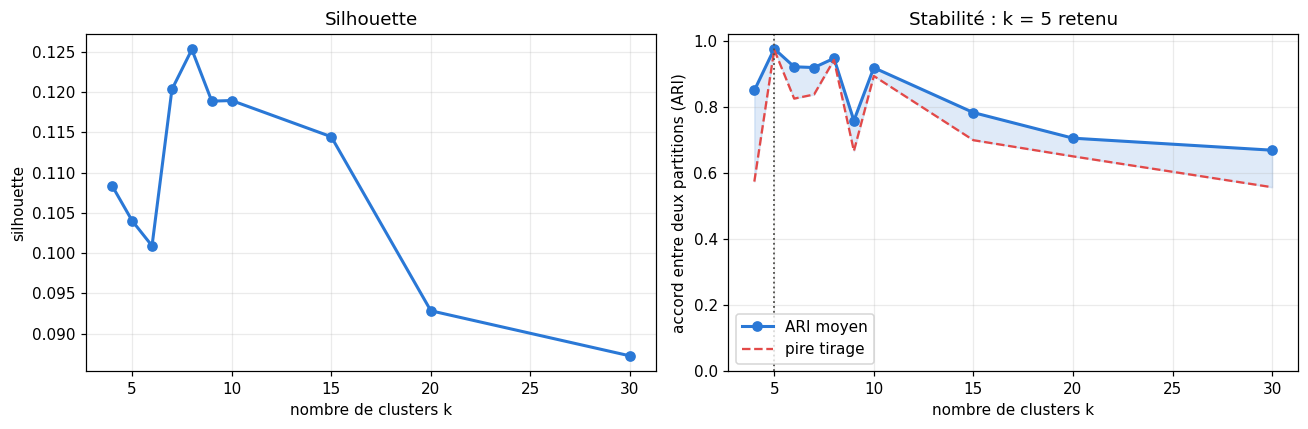

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_selection.index, k_selection["silhouette"], marker="o", color=BLEU, linewidth=2)
axes[0].set(xlabel="nombre de clusters k", ylabel="silhouette",
            title="Silhouette")

axes[1].fill_between(k_selection.index, k_selection["ari_min"], k_selection["ari_moyen"],
                     color=BLEU, alpha=0.15)
axes[1].plot(k_selection.index, k_selection["ari_moyen"], marker="o", color=BLEU, linewidth=2,
             label="ARI moyen")
axes[1].plot(k_selection.index, k_selection["ari_min"], linestyle="--", color=ROUGE, linewidth=1.5,
             label="pire tirage")
axes[1].axvline(N_CLUSTERS, color=ENCRE, linestyle=":", linewidth=1.2)
axes[1].set(xlabel="nombre de clusters k", ylabel="accord entre deux partitions (ARI)", ylim=(0, 1.02),
            title=f"Stabilité : k = {N_CLUSTERS} retenu")
axes[1].legend(loc="lower left")

for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()

## 6. Clustering final

In [93]:
kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, batch_size=1024, n_init=10
)
user_cluster_labels = kmeans.fit_predict(user_vectors)

user_clusters = pd.DataFrame(
    {"userId": [idx_to_user[i] for i in range(len(user_ids))], "cluster": user_cluster_labels}
)

print("Répartition des utilisateurs par cluster :")
user_clusters["cluster"].value_counts().sort_index()

Répartition des utilisateurs par cluster :


cluster
0    24542
1    32244
2    37501
3    49558
4    57103
Name: count, dtype: int64

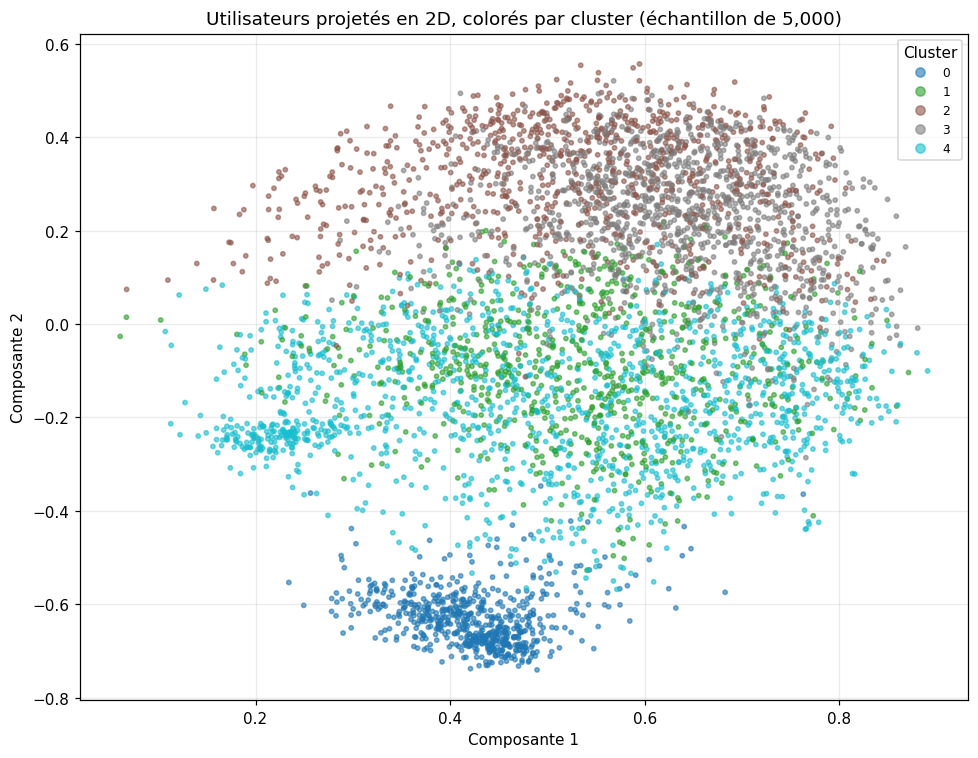

In [94]:
SCATTER_SAMPLE = 5_000  # nombre de points affichés (tout tracer serait illisible et lent)

rng_scatter = np.random.default_rng(RANDOM_STATE)
scatter_idx = rng_scatter.choice(len(user_vectors), min(SCATTER_SAMPLE, len(user_vectors)),
                                 replace=False)

# Projection 2D (uniquement pour la visu) d'un espace qui en a 50
coords_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit_transform(
    user_vectors[scatter_idx]
)
clusters_sample = user_cluster_labels[scatter_idx]

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    coords_2d[:, 0], coords_2d[:, 1],
    c=clusters_sample, cmap="tab10", s=8, alpha=0.6,
)
plt.title(f"Utilisateurs projetés en 2D, colorés par cluster (échantillon de {len(scatter_idx):,})")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.legend(*scatter.legend_elements(), title="Cluster", loc="best", fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Profil de goûts des clusters


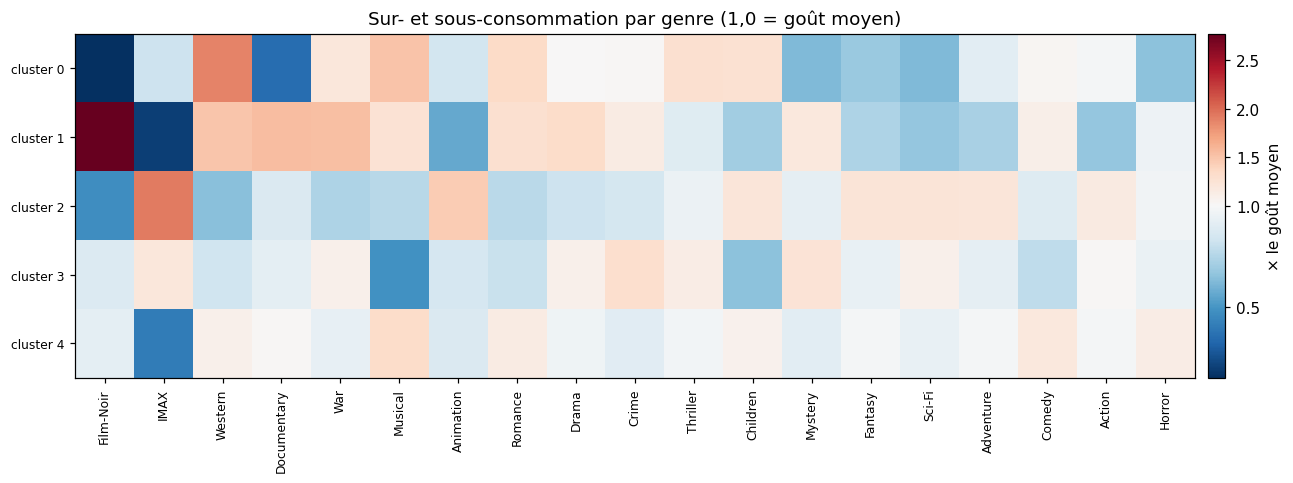

In [95]:
genre_pairs = movies.loc[movies["genres"].ne("(no genres listed)"), ["movieId", "genres"]].copy()
genre_pairs["genres"] = genre_pairs["genres"].str.split("|")
genre_pairs = genre_pairs.explode("genres").rename(columns={"genres": "genre"})
genre_pairs["genre"] = genre_pairs["genre"].astype("category")

liked = (ratings.loc[ratings["rating"] >= 4.0, ["userId", "movieId"]]
         .merge(user_clusters, on="userId").merge(genre_pairs, on="movieId"))
genre_volume = liked.groupby(["cluster", "genre"], observed=True).size().unstack("genre").fillna(0)
genre_share = genre_volume.div(genre_volume.sum(axis=1), axis=0)
overall_share = genre_volume.sum() / genre_volume.to_numpy().sum()
cluster_genre_profile = genre_share / overall_share

order = cluster_genre_profile.max().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(13, 0.42 * N_CLUSTERS + 2.4))
image = ax.imshow(cluster_genre_profile[order], aspect="auto", cmap="RdBu_r",
                  norm=TwoSlopeNorm(vcenter=1.0,
                                    vmin=cluster_genre_profile.to_numpy().min(),
                                    vmax=cluster_genre_profile.to_numpy().max()))
ax.set_xticks(range(len(order)), order, rotation=90, fontsize=8)
ax.set_yticks(range(len(cluster_genre_profile)),
              [f"cluster {i}" for i in cluster_genre_profile.index], fontsize=8)
ax.set_title("Sur- et sous-consommation par genre (1,0 = goût moyen)")
ax.grid(False)
fig.colorbar(image, ax=ax, pad=0.01, label="× le goût moyen")
plt.tight_layout()

## 8. Films de référence par cluster

In [96]:
def compute_cluster_top_movies(ratings_with_cluster, min_votes=MIN_VOTES_IN_CLUSTER):
    stats = (
        ratings_with_cluster.groupby(["cluster", "movieId"])["rating"]
        .agg(mean_rating="mean", n_votes="count")
        .reset_index()
    )
    cluster_global_mean = ratings_with_cluster.groupby("cluster")["rating"].mean().rename("cluster_mean")
    stats = stats.merge(cluster_global_mean, on="cluster")

    v, m, R, C = stats["n_votes"], min_votes, stats["mean_rating"], stats["cluster_mean"]
    stats["weighted_rating"] = (v / (v + m)) * R + (m / (v + m)) * C
    return stats


cluster_movie_stats = compute_cluster_top_movies(ratings.merge(user_clusters, on="userId"))
cluster_movie_stats = cluster_movie_stats.merge(movies[["movieId", "title", "genres"]], on="movieId")

cluster_movie_stats[cluster_movie_stats["cluster"] == 0].sort_values(
    "weighted_rating", ascending=False
).head(10)[["title", "genres", "mean_rating", "n_votes", "weighted_rating"]]

,title,genres,mean_rating,n_votes,weighted_rating
515,Schindler's List (1993),Drama|War,4.503602,10273,4.501744
310,"Shawshank Redemption, The (1994)",Crime|Drama,4.480643,15033,4.479403
693,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy,4.493796,806,4.470888
1100,Wallace & Gromit: The Wrong Trousers (1993),Animation|Children|Comedy|Crime,4.448718,351,4.400144
717,Wallace & Gromit: A Close Shave (1995),Animation|Children|Comedy,4.407154,657,4.381763
1145,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,4.321682,987,4.306309
49,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.294189,9482,4.292618
828,"Godfather, The (1972)",Crime|Drama,4.298797,748,4.279236
575,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,4.269884,16131,4.268990
772,Lone Star (1996),Drama|Mystery|Western,4.281250,656,4.259546


In [97]:
global_movie_stats = compute_cluster_top_movies(ratings.assign(cluster=0))[["movieId", "weighted_rating"]]
global_movie_stats = global_movie_stats.rename(columns={"weighted_rating": "global_weighted"})
cluster_movie_stats = cluster_movie_stats.merge(global_movie_stats, on="movieId", how="left")
cluster_movie_stats["distinctive_score"] = (
    cluster_movie_stats["weighted_rating"] - cluster_movie_stats["global_weighted"]
)


def describe_clusters(top_genres=5, top_movies=5, min_votes=50):
    for cluster_id in sorted(user_clusters["cluster"].unique()):
        size = (user_clusters["cluster"] == cluster_id).sum()
        top_g = cluster_genre_profile.loc[cluster_id].sort_values(ascending=False).head(top_genres)
        top_m = (
            cluster_movie_stats[
                (cluster_movie_stats["cluster"] == cluster_id)
                & (cluster_movie_stats["n_votes"] >= min_votes)
            ]
            .sort_values("distinctive_score", ascending=False)
            .head(top_movies)
        )

        print(f"\n=== Cluster {cluster_id} ({size:,} utilisateurs, {100 * size / len(user_clusters):.1f} %) ===")
        print("Genres sur-consommés :", ", ".join(f"{g} (x{v:.2f})" for g, v in top_g.items()))
        print("Films distinctifs :")
        for _, row in top_m.iterrows():
            print(f"  - {row['title']} (+{row['distinctive_score']:.2f} vs global, {row['n_votes']} votes)")


describe_clusters()


=== Cluster 0 (24,542 utilisateurs, 12.2 %) ===
Genres sur-consommés : Western (x1.88), Musical (x1.51), Romance (x1.34), Thriller (x1.29), Children (x1.28)
Films distinctifs :
  - Stupids, The (1996) (+0.90 vs global, 220 votes)
  - Batman & Robin (1997) (+0.86 vs global, 86 votes)
  - In the Army Now (1994) (+0.78 vs global, 50 votes)
  - Street Fighter (1994) (+0.76 vs global, 61 votes)
  - Volcano (1997) (+0.69 vs global, 74 votes)

=== Cluster 1 (32,244 utilisateurs, 16.0 %) ===
Genres sur-consommés : Film-Noir (x2.77), Documentary (x1.55), War (x1.53), Western (x1.49), Drama (x1.32)
Films distinctifs :
  - Big Top Pee-Wee (1988) (+0.58 vs global, 71 votes)
  - Amityville 3-D (1983) (+0.56 vs global, 51 votes)
  - Gigli (2003) (+0.55 vs global, 59 votes)
  - Pootie Tang (2001) (+0.54 vs global, 53 votes)
  - Glitter (2001) (+0.54 vs global, 76 votes)

=== Cluster 2 (37,501 utilisateurs, 18.7 %) ===
Genres sur-consommés : IMAX (x1.91), Animation (x1.44), Fantasy (x1.23), Sci-Fi (x

## 9. Recommandation pour un utilisateur

In [ ]:
_counts = liked.groupby(["userId", "genre"], observed=True).size()
user_genre_share = _counts / _counts.groupby(level=0).transform("sum")
movie_genres_map = genre_pairs.groupby("movieId", observed=True)["genre"].agg(list)


def get_user_genre_affinity(user_id):
    try:
        return user_genre_share.loc[user_id].to_dict()
    except KeyError:
        return {}


def recommend_for_user(user_id, n=TOP_N_RECOMMENDATIONS, affinity_weight=0.5):
    cluster_id = user_clusters.loc[user_clusters["userId"] == user_id, "cluster"]
    if cluster_id.empty:
        raise ValueError(f"Utilisateur {user_id} inconnu.")
    cluster_id = cluster_id.iloc[0]

    already_rated = set(ratings.loc[ratings["userId"] == user_id, "movieId"])
    affinity = get_user_genre_affinity(user_id)

    candidates = cluster_movie_stats[
        (cluster_movie_stats["cluster"] == cluster_id)
        & (~cluster_movie_stats["movieId"].isin(already_rated))
        & (cluster_movie_stats["n_votes"] >= MIN_VOTES_IN_CLUSTER)
    ].copy()

    candidates["genre_affinity"] = [
        sum(affinity.get(g, 0.0) for g in movie_genres_map.get(m, []))
        for m in candidates["movieId"]
    ]
    candidates["final_score"] = candidates["weighted_rating"] * (
        1 + affinity_weight * candidates["genre_affinity"]
    )

    return (candidates.sort_values("final_score", ascending=False).head(n)
            [["movieId", "title", "genres", "weighted_rating", "genre_affinity", "final_score", "n_votes"]]
            .reset_index(drop=True))


example_user_id = int(ratings["userId"].iloc[0])
cluster_exemple = user_clusters.set_index("userId").loc[example_user_id, "cluster"]
print(f"Recommandations pour l'utilisateur {example_user_id} (cluster {cluster_exemple}) :")
recommend_for_user(example_user_id)

Recommandations pour l'utilisateur 1 (cluster 1) :


,movieId,title,genres,weighted_rating,genre_affinity,final_score,n_votes
0,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,4.250365,0.584211,5.491919,3939
1,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.250925,0.578947,5.481456,16683
2,3307,City Lights (1931),Comedy|Drama|Romance,4.242089,0.584211,5.481225,1567
3,3462,Modern Times (1936),Comedy|Drama|Romance,4.226446,0.584211,5.461013,1999
4,1244,Manhattan (1979),Comedy|Drama|Romance,4.168519,0.584211,5.386165,5304
5,1224,Henry V (1989),Action|Drama|Romance|War,4.164348,0.573684,5.358858,2555
6,2019,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama,4.350499,0.463158,5.357984,5778
7,6016,City of God (Cidade de Deus) (2002),Action|Adventure|Crime|Drama|Thriller,4.177449,0.563158,5.353730,3306
8,903,Vertigo (1958),Drama|Mystery|Romance|Thriller,4.255214,0.515789,5.352612,7976
9,858,"Godfather, The (1972)",Crime|Drama,4.484442,0.384211,5.345927,17579


## 10. Évaluation

In [99]:
K_EVAL, RATING_THRESHOLD, N_EVAL_USERS = 10, 4.0, 2000

shuffled = np.random.default_rng(RANDOM_STATE).permutation(len(ratings))
cut = int(0.8 * len(ratings))
train_ratings = ratings.iloc[shuffled[:cut]]
test_ratings = ratings.iloc[shuffled[cut:]]

train_users = np.sort(train_ratings["userId"].unique())
train_movies = np.sort(train_ratings["movieId"].unique())
train_matrix = csr_matrix(
    (np.ones(len(train_ratings), dtype=np.float32),
     (train_ratings["userId"].map({u: i for i, u in enumerate(train_users)}).to_numpy(),
      train_ratings["movieId"].map({m: i for i, m in enumerate(train_movies)}).to_numpy())),
    shape=(len(train_users), len(train_movies)))

train_vectors = normalize(TruncatedSVD(N_COMPONENTS, random_state=RANDOM_STATE).fit_transform(train_matrix))
train_labels = MiniBatchKMeans(N_CLUSTERS, random_state=RANDOM_STATE, batch_size=1024,
                               n_init=10).fit_predict(train_vectors)
cluster_of = pd.Series(train_labels, index=train_users)
print(f"Clustering réappris sur le train seul : {len(train_users):,} utilisateurs, k={N_CLUSTERS}")

Clustering réappris sur le train seul : 200,948 utilisateurs, k=5


In [100]:
def bayesian_ranking(block, reference_mean, m=MIN_VOTES_IN_CLUSTER):
    """Classement des films d'un bloc par note pondere bayesienne."""
    stats = block.groupby("movieId")["rating"].agg(["mean", "count"])
    v = stats["count"]
    return ((v / (v + m)) * stats["mean"] + (m / (v + m)) * reference_mean).sort_values(ascending=False)


train_with_cluster = train_ratings.assign(cluster=train_ratings["userId"].map(cluster_of))
cluster_rankings = {c: bayesian_ranking(block, block["rating"].mean())
                    for c, block in train_with_cluster.groupby("cluster")}
global_ranking = bayesian_ranking(train_ratings, train_ratings["rating"].mean())

seen_in_train = train_ratings.groupby("userId")["movieId"].agg(set)
liked_in_test = test_ratings[test_ratings["rating"] >= RATING_THRESHOLD].groupby("userId")["movieId"].agg(set)
eligible = [u for u in liked_in_test.index if u in cluster_of.index and u in seen_in_train.index]
eval_users = pd.Series(eligible).sample(min(N_EVAL_USERS, len(eligible)), random_state=RANDOM_STATE)


def precision_at_k(user_id, ranking, k=K_EVAL):
    """Part des k films recommandes que l'utilisateur a reellement aimes dans le test."""
    seen = seen_in_train.loc[user_id]
    recommended = [m for m in ranking.index if m not in seen][:k]
    return len(set(recommended) & liked_in_test.loc[user_id]) / k


scores = pd.DataFrame({
    "par cluster": [precision_at_k(u, cluster_rankings[cluster_of.loc[u]]) for u in eval_users],
    "popularité globale": [precision_at_k(u, global_ranking) for u in eval_users],
})

summary = pd.DataFrame({
    "precision@10": scores.mean(),
    "ic_95_bas": scores.mean() - 1.96 * scores.sem(),
    "ic_95_haut": scores.mean() + 1.96 * scores.sem(),
})
ecart = scores["par cluster"] - scores["popularité globale"]
print(f"{len(eval_users):,} utilisateurs évalués, vivier de candidats identique pour les deux méthodes")
print(f"écart moyen : {ecart.mean():+.4f} (IC 95 % : {ecart.mean() - 1.96 * ecart.sem():+.4f} "
      f"à {ecart.mean() + 1.96 * ecart.sem():+.4f})")
summary.round(4)

2,000 utilisateurs évalués, vivier de candidats identique pour les deux méthodes
écart moyen : +0.0226 (IC 95 % : +0.0194 à +0.0257)


,precision@10,ic_95_bas,ic_95_haut
par cluster,0.0476,0.0438,0.0515
popularité globale,0.0251,0.0227,0.0275


L'écart entre les deux méthodes se lit désormais avec son intervalle de confiance. **Si l'intervalle de l'écart
contient zéro, l'apport du clustering n'est pas démontré** sur ce protocole — et c'est une conclusion recevable,
à condition d'être énoncée plutôt que masquée.

Une limite subsiste, commune aux deux méthodes : le découpage train/test est **aléatoire**, donc on prédit du
passé avec du futur. Pour un recommandeur, un découpage **temporel** (entraîner sur les notes antérieures à une
date, tester après) est plus proche de l'usage réel, et c'est le protocole déjà retenu sur la partie prédiction
du succès. C'est le prochain correctif à apporter.

## 11. Distance entre clusters

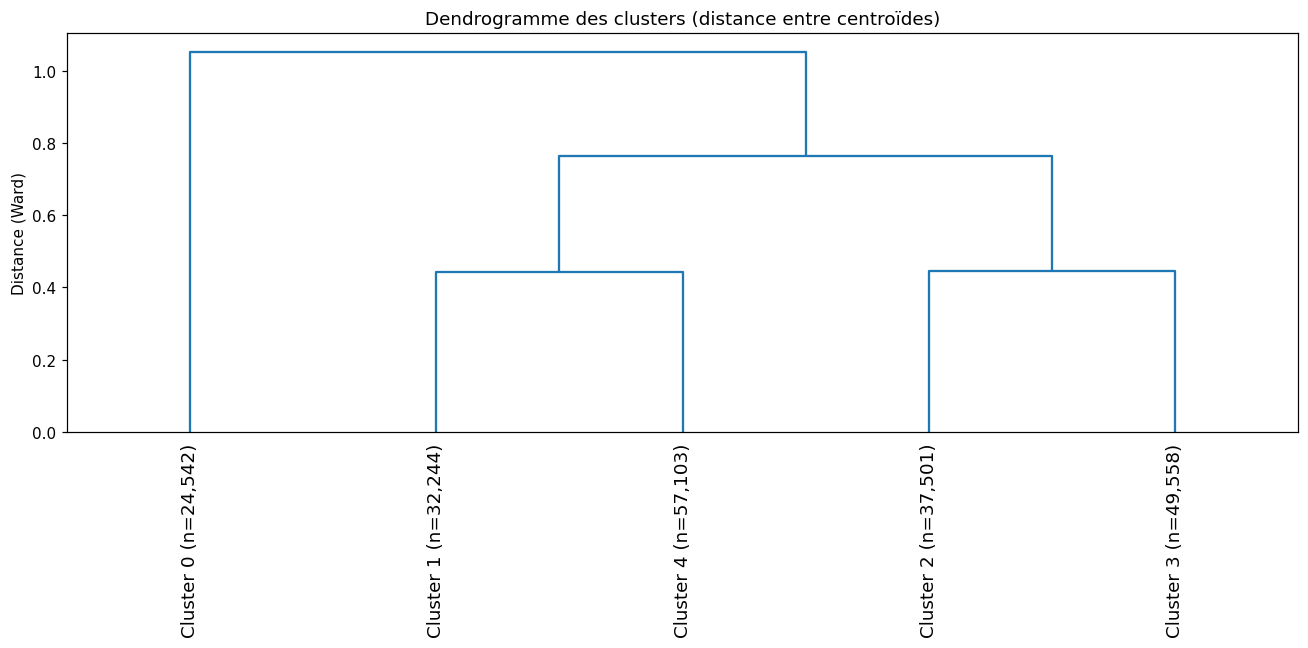

In [101]:
cluster_sizes = user_clusters["cluster"].value_counts().sort_index()
dendro_labels = [f"Cluster {i} (n={cluster_sizes.get(i, 0):,})" for i in range(N_CLUSTERS)]

Z = linkage(kmeans.cluster_centers_, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=dendro_labels, leaf_rotation=90, color_threshold=0)
plt.title("Dendrogramme des clusters (distance entre centroïdes)")
plt.ylabel("Distance (Ward)")
plt.grid(False)
plt.tight_layout()
plt.show()

## 12. Sauvegarde

In [102]:
os.makedirs("models", exist_ok=True)
with open("models/clustering_recommender.pkl", "wb") as f:
    pickle.dump(
        {
            "svd": svd,
            "kmeans": kmeans,
            "n_clusters": N_CLUSTERS,
            "normalisation": "L2 sur la sortie SVD (pas de StandardScaler)",
            "matrice": "binaire vu / pas vu",
            "user_to_idx": user_to_idx,
            "movie_to_idx": movie_to_idx,
            "user_clusters": user_clusters,
            "cluster_movie_stats": cluster_movie_stats,
            "cluster_genre_profile": cluster_genre_profile,
        },
        f,
    )

print("Modèle sauvegardé dans models/clustering_recommender.pkl")

Modèle sauvegardé dans models/clustering_recommender.pkl
